In [50]:
from gomoku import Gomoku
from mcts import Tree
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
class Player:
    def next_move(self, game: Gomoku) -> tuple[int, int]:
        raise NotImplementedError

class RandomPlayer(Player):
    def next_move(self, game: Gomoku) -> tuple[int, int]:
        moves = game.actions()
        random_move  = np.random.randint(0, len(moves))
        return moves[random_move]
    
class FlatPlayer(Player):
    def __init__(self, max_moves: int = 0):
        self.max_moves = max_moves
    
    def next_move(self, game: Gomoku):
        moves = game.actions()
        if self.max_moves:
            moves = moves[:self.max_moves]
        
        max_reward = -np.inf
        argmax_reward = None
        
        for move in moves:
            new_game = game.copy()
            reward, _ = new_game.play(move)
            if reward > max_reward:
                max_reward = reward
                argmax_reward = move
        
        if argmax_reward is not None:
            move = argmax_reward
        else:
            move = moves[np.random.randint(0, len(moves))]
        
        return move
            
class MCTSPlayer(Player):
    def __init__(self, iterations=1000):
        self.iterations = iterations

    def next_move(self, game: Gomoku):
        tree = Tree(game)
        for _ in range(self.iterations):
            node = tree.select()
            value = tree.simulate(node)
            tree.backpropagate(node, value)
        best_child = max(tree.root.children, key=lambda child: child.Q)
        return best_child.state.history[-1]

In [56]:
def play_game(game: Gomoku, player1: Player, player2: Player, print: bool = False):
    while not game.fin():
        if game.player == 1:
            move = player1.next_move(game)
        else:
            move = player2.next_move(game)
        game.play(move)
        
    if print:
        game.print()
    return game.winner

def play_n_games(game: Gomoku, player1: Player, player2: Player, n: int, print: bool = False):
    avg = 0
    avgs = []
    for i in range(n):
        score = (play_game(game.copy(), player1, player2, print) + 1) / 2
        avg *= i / (i + 1)
        avg += score / (i + 1)
        avgs += [avg]
    return avgs

def time_series_plot(ax, arr: list[float], title: str = ""):
    ax.plot(arr)
    ax.set_title(title)
    ax.set_xlabel("Game")
    ax.set_ylabel("Average score")

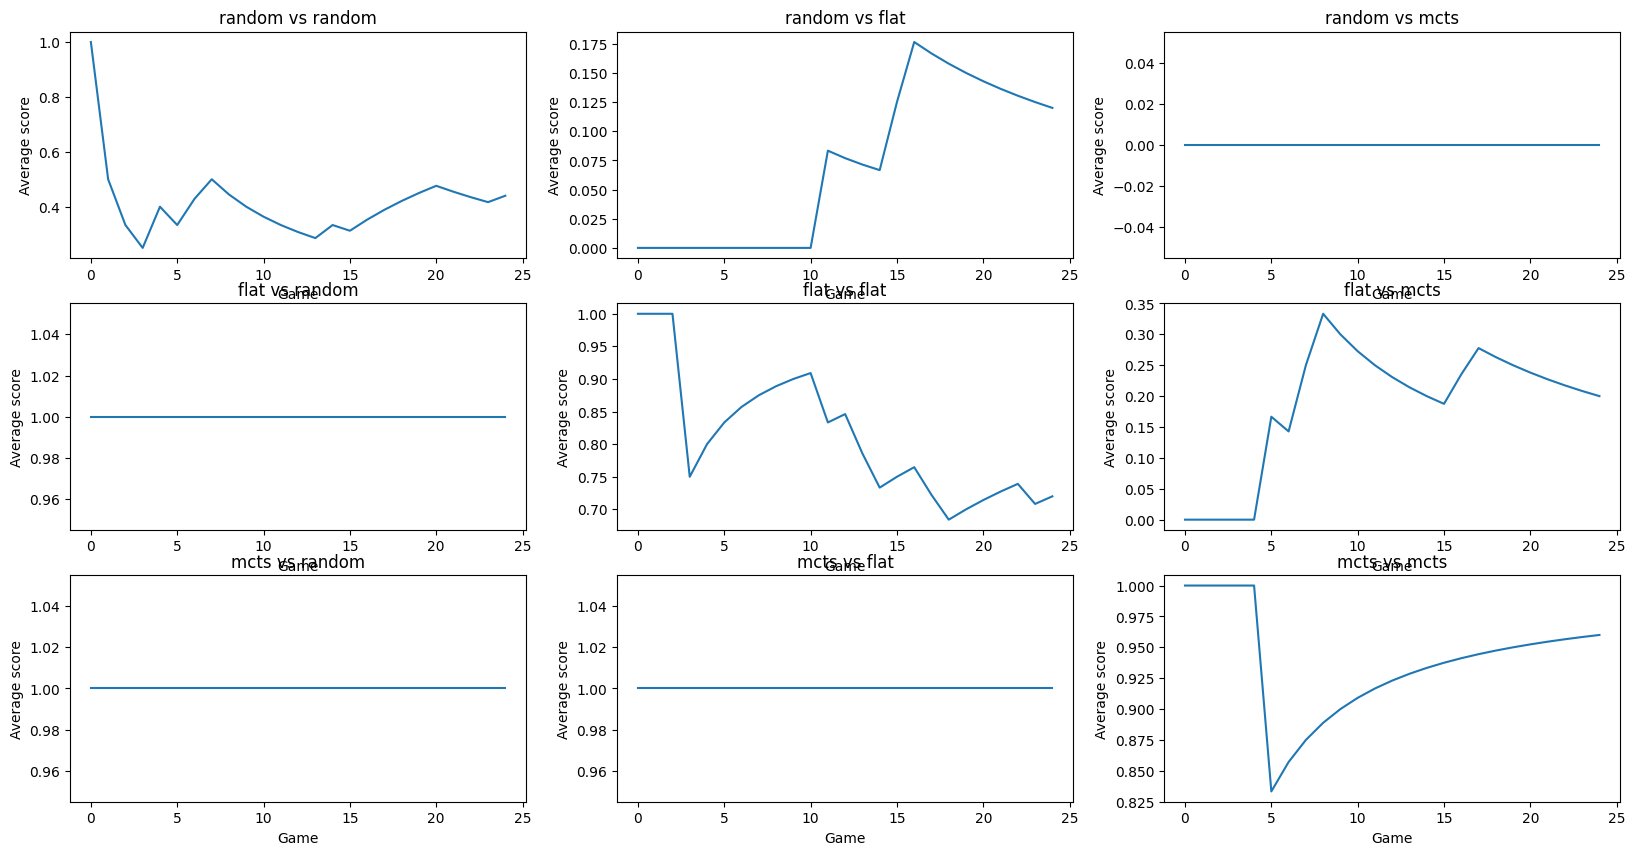

In [57]:
players = {
    "random": RandomPlayer(), # plays randomly
    "flat": FlatPlayer(), # checks if any move is winning
    "mcts": MCTSPlayer(), # uses MCTS to evaluate the best move
}

n = 25

# scores = {}
# for k in tqdm(range(len(players) ** 2)):
#     player_list, n_players = list(players), len(players)
#     i, j = k // n_players, k % n_players
#     playerI, playerJ = player_list[i], player_list[j]
#     game = Gomoku(
#         M=5,
#         N=5,
#         K=3,
#         FIRST_PLAYER=1,
#     )
#     score = play_n_games(game, players[playerI], players[playerJ], n, print=False)
#     scores[(playerI, playerJ)] = score
#
# fig, axes = plt.subplots(len(players), len(players), figsize=(20, 10))
# player_nums = dict([(v, i) for i, v in enumerate(players)])
# for k, v in scores.items():
#     playerI, playerJ = k
#     ax = axes[player_nums[playerI],  player_nums[playerJ]]
#     time_series_plot(ax, v, f"{playerI} vs {playerJ}")
# plt.show()